# 🦙 Finetuning Llama 3.2-1B — Detecção de UDPLag

**Checklist antes de rodar:**
- [ ] `Runtime → Change runtime type → T4 GPU`
- [ ] Upload do `finetune_dataset_udplag.jsonl` na barra lateral esquerda

Rode as células **em ordem**.

## Célula 1 — Instalar dependências

In [ ]:
%%capture
!pip install unsloth trl datasets
print('✅ Instalação concluída!')

## Célula 2 — Verificar GPU

In [ ]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError('❌ GPU não encontrada! Vá em Runtime → Change runtime type → T4 GPU')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'✅ GPU: {gpu_name}')
print(f'   VRAM: {vram_gb:.1f} GB')
print(f'   BF16 suportado: {torch.cuda.is_bf16_supported()}')

✅ GPU: Tesla T4
   VRAM: 15.6 GB
   BF16 suportado: True


## Célula 3 — Verificar dataset

In [ ]:
import os, json

DATASET_PATH = '/content/finetune_dataset_udplag.jsonl'

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        '❌ finetune_dataset_udplag.jsonl não encontrado!\n'
        'Clique no ícone de pasta na barra esquerda e faça upload do arquivo.'
    )

records = []
with open(DATASET_PATH) as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

benign = sum(1 for r in records if json.loads(r['messages'][2]['content'])['classification'] == 'BENIGN')
udplag = len(records) - benign

print(f'✅ Dataset carregado!')
print(f'   Total:  {len(records)} exemplos')
print(f'   BENIGN: {benign}')
print(f'   UDPLag: {udplag}')
print(f'\n📋 Exemplo:')
print(json.dumps(records[0], indent=2))

✅ Dataset carregado!
   Total:  2996 exemplos
   BENIGN: 1498
   UDPLag: 1498

📋 Exemplo:
{
  "messages": [
    {
      "role": "system",
      "content": "You are a network security analyst specialized in detecting UDPLag DDoS attacks. Analyze network flow features and respond only with a valid JSON object with the field 'classification', which must be exactly 'BENIGN' or 'UDPLag'."
    },
    {
      "role": "user",
      "content": "Given this network flow data, classify the traffic as benign or UDPLag flooding attack.\n\n- Min Packet Length: 375.0 bytes\n- Average Forward Segment Size: 375.0 bytes\n- Flow Bytes per Second: 250000000.0\n- URG Flag Count: 0.0\n- Forward Packets per Second: 666666.67\n\nReturn only valid JSON with the classification field."
    },
    {
      "role": "assistant",
      "content": "{\"classification\": \"UDPLag\"}"
    }
  ]
}


## Célula 4 — Carregar modelo + aplicar LoRA

In [ ]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template

MAX_SEQ_LENGTH = 512

print('🔄 Baixando modelo base (~800MB)...')

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = 'unsloth/Llama-3.2-1B-Instruct',
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = True,
    dtype          = None,
)

tokenizer = get_chat_template(tokenizer, chat_template='llama-3.2')
print('✅ Modelo carregado!')

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    lora_alpha     = 16,
    lora_dropout   = 0,
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                      'gate_proj', 'up_proj', 'down_proj'],
    bias           = 'none',
    use_gradient_checkpointing = 'unsloth',
    random_state   = 42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'✅ LoRA aplicado!')
print(f'   Parâmetros treináveis: {trainable:,} ({100*trainable/total:.2f}% do total)')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
🔄 Baixando modelo base (~800MB)...
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

✅ Modelo carregado!


Unsloth 2026.2.1 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


✅ LoRA aplicado!
   Parâmetros treináveis: 11,272,192 (1.43% do total)


## Célula 5 — Preparar dataset

In [ ]:
from datasets import Dataset

def format_example(example):
    text = tokenizer.apply_chat_template(
        example['messages'],
        tokenize=False,
        add_generation_prompt=False
    )
    return {'text': text}

raw_dataset = Dataset.from_list(records)
dataset     = raw_dataset.map(format_example, remove_columns=['messages'])

split      = dataset.train_test_split(test_size=0.1, seed=42)
train_data = split['train']
eval_data  = split['test']

print(f'✅ Dataset formatado!')
print(f'   Treino:    {len(train_data)} exemplos')
print(f'   Validação: {len(eval_data)} exemplos')
print(f'\n📋 Exemplo tokenizado (primeiros 300 chars):')
print(train_data[0]['text'][:300])

Map:   0%|          | 0/2996 [00:00<?, ? examples/s]

✅ Dataset formatado!
   Treino:    2696 exemplos
   Validação: 300 exemplos

📋 Exemplo tokenizado (primeiros 300 chars):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

You are a network security analyst specialized in detecting UDPLag DDoS attacks. Analyze network flow features and respond only with a valid JSON object with the field 'classi


## Célula 6 — Treinar

⏱️ **Estimativa na T4: ~10-20 minutos** (dataset menor que SYN)

Acompanhe o `loss` — deve cair rapidamente. Bom resultado: `loss < 0.1` ao final.

In [ ]:
import torch
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

torch._dynamo.config.disable = True
model.config.use_cache = False

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_data,
    eval_dataset  = eval_data,
    args = SFTConfig(
        dataset_text_field          = 'text',
        max_seq_length              = 512,
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 4,
        num_train_epochs            = 3,
        learning_rate               = 2e-4,
        warmup_ratio                = 0.05,
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        logging_steps               = 50,
        eval_strategy               = 'steps',
        eval_steps                  = 100,
        save_strategy               = 'steps',
        save_steps                  = 100,
        save_total_limit            = 2,
        load_best_model_at_end      = True,
        output_dir                  = '/content/llama-udplag-finetuned',
        report_to                   = 'none',
        seed                        = 42,
        optim                       = 'adamw_8bit',
        lr_scheduler_type           = 'cosine',
        weight_decay                = 0.01,
        dataset_num_proc            = 2,
        packing                     = False,
        group_by_length             = False,
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = '<|start_header_id|>user<|end_header_id|>\n\n',
    response_part    = '<|start_header_id|>assistant<|end_header_id|>\n\n',
)

# Verificar máscara
sample_batch = trainer.train_dataset[0]
labels = sample_batch.get('labels', None)
if labels is not None:
    masked = sum(1 for l in labels if l == -100)
    total  = len(labels)
    print(f'✅ Máscara aplicada: {masked}/{total} tokens mascarados ({100*masked/total:.0f}%)')
    print(f'   Tokens de treino: {total - masked} (só a resposta do assistant)')
else:
    print('⚠️ Labels não encontradas no batch')

print('\n🚀 Iniciando treinamento...')
stats = trainer.train()

print(f'\n✅ Treinamento concluído!')
print(f'   Tempo:      {stats.metrics["train_runtime"]/60:.1f} min')
print(f'   Loss final: {stats.metrics["train_loss"]:.4f}')

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/2696 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/300 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=6):   0%|          | 0/2696 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/2696 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,696 | Num Epochs = 3 | Total steps = 507
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,0.024400,0.015900
200,0.010700,0.005081
300,0.007500,0.004560
400,0.003500,0.004233
500,0.005100,0.004091


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient



✅ Treinamento concluído!
   Tempo:      17.9 min
   Loss final: 0.0218


## Célula 7 — Teste rápido pós-treino

In [ ]:
from unsloth import FastLanguageModel
import torch, json

FastLanguageModel.for_inference(model)

SYSTEM = (
    'You are a network security analyst specialized in detecting UDPLag DDoS attacks. '
    'Analyze network flow features and respond only with a valid JSON object with the field '
    "'classification', which must be exactly 'BENIGN' or 'UDPLag'."
)

# 5 BENIGN + 5 UDPLag do dataset real
test_samples = (
    [r for r in records if json.loads(r['messages'][2]['content'])['classification'] == 'BENIGN'][:5] +
    [r for r in records if json.loads(r['messages'][2]['content'])['classification'] == 'UDPLag'][:5]
)

print('🧪 Testando com exemplos reais do dataset:\n')
acertos = 0

for r in test_samples:
    true_label = json.loads(r['messages'][2]['content'])['classification']

    messages = [
        {'role': 'system', 'content': SYSTEM},
        {'role': 'user',   'content': r['messages'][1]['content']},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt').to('cuda')

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=32, temperature=0.1, do_sample=True)

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

    try:
        predicted_label = json.loads(response).get('classification', 'ERRO')
    except:
        predicted_label = 'ERRO'

    acerto = '✅' if predicted_label == true_label else '❌'
    if predicted_label == true_label:
        acertos += 1

    print(f'{acerto} Esperado: {true_label:6} | Previsto: {predicted_label}')

print(f'\n📊 Acurácia rápida: {acertos}/10 ({acertos*10}%)')

🧪 Testando com exemplos reais do dataset:

✅ Esperado: BENIGN | Previsto: BENIGN
✅ Esperado: BENIGN | Previsto: BENIGN
✅ Esperado: BENIGN | Previsto: BENIGN
✅ Esperado: BENIGN | Previsto: BENIGN
✅ Esperado: BENIGN | Previsto: BENIGN
✅ Esperado: UDPLag | Previsto: UDPLag
✅ Esperado: UDPLag | Previsto: UDPLag
✅ Esperado: UDPLag | Previsto: UDPLag
✅ Esperado: UDPLag | Previsto: UDPLag
✅ Esperado: UDPLag | Previsto: UDPLag

📊 Acurácia rápida: 10/10 (100%)


## Célula 8 — Avaliação final com test_dataset_udplag.jsonl

📂 Test dataset: 750 exemplos

  Progresso: 100/750
  Progresso: 200/750
  Progresso: 300/750
  Progresso: 400/750
  Progresso: 500/750
  Progresso: 600/750
  Progresso: 700/750

📊 Resultado final:
              precision    recall  f1-score   support

      BENIGN       0.98      0.99      0.99       375
      UDPLag       0.99      0.98      0.99       375

    accuracy                           0.99       750
   macro avg       0.99      0.99      0.99       750
weighted avg       0.99      0.99      0.99       750



<Figure size 600x600 with 0 Axes>

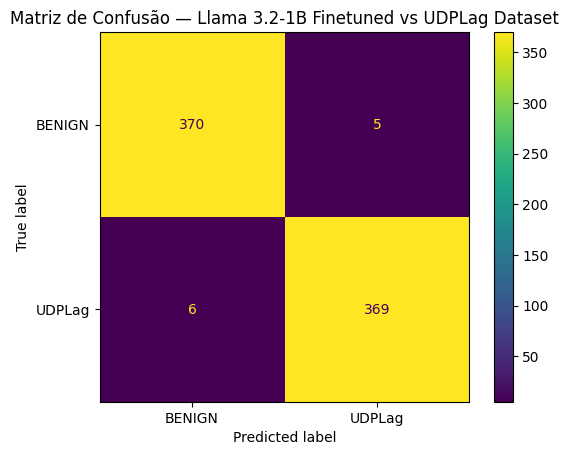

✅ Matriz salva!


In [ ]:
import json, torch
from unsloth import FastLanguageModel
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

FastLanguageModel.for_inference(model)

SYSTEM = (
    'You are a network security analyst specialized in detecting UDPLag DDoS attacks. '
    'Analyze network flow features and respond only with a valid JSON object with the field '
    "'classification', which must be exactly 'BENIGN' or 'UDPLag'."
)

test_records = []
with open('/content/test_dataset_udplag.jsonl') as f:
    for line in f:
        if line.strip():
            test_records.append(json.loads(line))

print(f'📂 Test dataset: {len(test_records)} exemplos\n')

y_true, y_pred = [], []

for i, r in enumerate(test_records):
    true_label = json.loads(r['messages'][2]['content'])['classification']

    messages = [
        {'role': 'system', 'content': SYSTEM},
        {'role': 'user',   'content': r['messages'][1]['content']},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt').to('cuda')

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=32, temperature=0.0, do_sample=False)

    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

    try:
        predicted_label = json.loads(response).get('classification', 'BENIGN')
    except:
        predicted_label = 'BENIGN'

    y_true.append(true_label)
    y_pred.append(predicted_label)

    if (i + 1) % 100 == 0:
        print(f'  Progresso: {i+1}/{len(test_records)}')

print('\n📊 Resultado final:')
print(classification_report(y_true, y_pred, labels=['BENIGN', 'UDPLag']))

cm = confusion_matrix(y_true, y_pred, labels=['BENIGN', 'UDPLag'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN', 'UDPLag'])
plt.figure(figsize=(6, 6))
disp.plot(values_format='d')
plt.title('Matriz de Confusão — Llama 3.2-1B Finetuned vs UDPLag Dataset')
plt.savefig('/content/confusion_matrix_udplag.png', dpi=150)
plt.show()
print('✅ Matriz salva!')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=["BENIGN", "UDPLag"], digits=4))

              precision    recall  f1-score   support

      BENIGN     0.9840    0.9867    0.9854       375
      UDPLag     0.9866    0.9840    0.9853       375

    accuracy                         0.9853       750
   macro avg     0.9853    0.9853    0.9853       750
weighted avg     0.9853    0.9853    0.9853       750



## Célula 9 — Exportar GGUF para Ollama

⏱️ ~16 minutos. Depois baixe o `.gguf` pela barra lateral esquerda.

In [ ]:
print('📦 Exportando para GGUF Q4_K_M...')

model.save_pretrained_gguf(
    '/content/llama-udplag-gguf',
    tokenizer,
    quantization_method='q4_k_m'
)

import os
gguf_files = [f for f in os.listdir('/content/llama-udplag-gguf') if f.endswith('.gguf')]
sizes      = [os.path.getsize(f'/content/llama-udplag-gguf/{f}') / 1e9 for f in gguf_files]

print(f'\n✅ GGUF gerado!')
for name, size in zip(gguf_files, sizes):
    print(f'   {name} ({size:.2f} GB)')

print(f'\n📥 Para baixar:')
print(f'   Barra lateral esquerda → pasta llama-udplag-gguf → clique direito no .gguf → Download')
print(f'\n📋 Depois na sua máquina:')
print(f'   1. Crie um Modelfile com: FROM ./nome-do-arquivo.gguf')
print(f'   2. ollama create llama-udplag-finetuned -f Modelfile')